In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from pandas.plotting import scatter_matrix

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_samples

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
csv_path = "sample_data/matches_laliga.csv"
df = pd.read_csv(csv_path)
df.head()

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,...,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2025-08-16,19:30,La Liga,Matchweek 1,Sat,Away,W,3.0,0.0,...,Match Report,NaN,24.0,8.0,18.9,1.0,0,0,2025,Barcelona
1,1,2025-08-23,21:30,La Liga,Matchweek 2,Sat,Away,W,3.0,2.0,...,Match Report,NaN,26.0,10.0,17.0,1.0,0,0,2025,Barcelona
2,2,2025-08-31,21:30,La Liga,Matchweek 3,Sun,Away,D,1.0,1.0,...,Match Report,NaN,11.0,2.0,20.3,0.0,1,1,2025,Barcelona
3,3,2025-09-14,21:00,La Liga,Matchweek 4,Sun,Home,W,6.0,0.0,...,Match Report,NaN,24.0,10.0,18.4,0.0,0,0,2025,Barcelona
4,5,2025-09-21,21:00,La Liga,Matchweek 5,Sun,Home,W,3.0,0.0,...,Match Report,NaN,16.0,7.0,18.2,2.0,0,0,2025,Barcelona


In [ ]:

df = df.copy()
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()

,date,time,comp,round,day,venue,result,gf,ga,opponent,...,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,2025-08-16,19:30,La Liga,Matchweek 1,Sat,Away,W,3.0,0.0,Mallorca,...,Match Report,NaN,24.0,8.0,18.9,1.0,0,0,2025,Barcelona
1,2025-08-23,21:30,La Liga,Matchweek 2,Sat,Away,W,3.0,2.0,Levante,...,Match Report,NaN,26.0,10.0,17.0,1.0,0,0,2025,Barcelona
2,2025-08-31,21:30,La Liga,Matchweek 3,Sun,Away,D,1.0,1.0,Rayo Vallecano,...,Match Report,NaN,11.0,2.0,20.3,0.0,1,1,2025,Barcelona
3,2025-09-14,21:00,La Liga,Matchweek 4,Sun,Home,W,6.0,0.0,Valencia,...,Match Report,NaN,24.0,10.0,18.4,0.0,0,0,2025,Barcelona
4,2025-09-21,21:00,La Liga,Matchweek 5,Sun,Home,W,3.0,0.0,Getafe,...,Match Report,NaN,16.0,7.0,18.2,2.0,0,0,2025,Barcelona




# Preprocesamiento

Antes de aplicar los modelos debemos hacer un preprocesamiento de los datos.

Empezamos filtrando solo las filas donde (venue == "home"), para no tener duplicados. Ahora solo hay una fila por partido, quedándonos solo con el equipo local de cada partido. Antes habían dos filas para un mismo partido (fila del equipo local y fila del equipo visitante).

También se calcula la variable objetivo, total de goles, como la suma de los goles en contra y a favor.


In [ ]:
home_rows = df[df["venue"].str.lower()=="home"].copy()
home_rows["home_team"]  = home_rows["team"]
home_rows["away_team"]  = home_rows["opponent"]
home_rows["home_goals"] = home_rows["gf"].astype(float)
home_rows["away_goals"] = home_rows["ga"].astype(float)
home_rows["total_goals"] = home_rows["home_goals"] + home_rows["away_goals"]
home_rows = home_rows.sort_values("date").reset_index(drop=True)

print("Partidos (match-level):", len(home_rows))
print("Temporadas:", sorted(home_rows["season"].dropna().unique().tolist()))

Partidos (match-level): 2350
Temporadas: [2019, 2020, 2021, 2022, 2023, 2024, 2025]


## Creación nuevas variables
Creamos una variable numérica nueva (points), a partir de la variable "Result", donde son 3 puntos si ganas el partido, 1 si lo empatas y 0 si lo pierdes.

También creamos variables que nos indica el estado de forma actual de los equipos, calculando el promedio de los goles a favor y en contra en sus últimos 5 partidos y el promedio de puntos del último partido.

Por último, hemos querido añadir la variable dias de descanso, ya que creemos que es muy importante saber la fatiga del equipo.

In [ ]:
points_map = {"W":3, "D":1, "L":0}
df["points"] = df["result"].map(points_map)

df = df.sort_values(["team","date"])
g = df.groupby("team", group_keys=False)

df["gf5"]   = g["gf"].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
df["ga5"]   = g["ga"].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
df["pts5"]  = g["points"].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
# Descanso entre partidos por equipo usando 'date'
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["prev_date"] = g["date"].shift(1)
df["rest_days"] = (df["date"] - df["prev_date"]).dt.days

g_season = df.groupby(['season', 'team'])

# Calculamos los totales
df['gf_total'] = g_season['gf'].transform(lambda x: x.shift(1).cumsum())
df['ga_total'] = g_season['ga'].transform(lambda x: x.shift(1).cumsum())
df['pts_total'] = g_season['points'].transform(lambda x: x.shift(1).cumsum())
cols_total = ['gf_total', 'ga_total', 'pts_total']
df[cols_total] = df[cols_total].fillna(0)

team_feats = df[["team","date","gf5","ga5","pts5","rest_days"]].copy()
barca = team_feats[team_feats["team"] == "Barcelona"].sort_values("date")

print(barca[["date", "gf5", "ga5", "pts5", "rest_days"]].tail(10))


          date  gf5  ga5  pts5  rest_days
175 2025-05-15  2.4  1.4   3.0        4.0
176 2025-05-18  2.6  1.4   3.0        3.0
177 2025-05-25  2.2  1.4   2.4        7.0
0   2025-08-16  2.6  1.4   2.4       83.0
1   2025-08-23  2.8  1.2   2.4        7.0
2   2025-08-31  2.6  1.0   2.4        8.0
3   2025-09-14  2.4  1.2   2.0       14.0
4   2025-09-21  3.2  0.6   2.6        7.0
5   2025-09-25  3.2  0.6   2.6        4.0
6   2025-09-28  3.2  0.8   2.6        3.0


Combinamos los dos data-sets que hemos generado previamente (team_feats y home_rows), para tener toda la información sobre un partido en una misma fila.

In [ ]:
# Actualizamos team_feats
team_feats = df[["team", "date", "gf5", "ga5", "pts5", "rest_days", "gf_total", "ga_total", "pts_total"]].copy()

# merge
home_rows["date"] = pd.to_datetime(home_rows["date"], errors="coerce").dt.normalize()

data_matches = home_rows.merge(
    team_feats.rename(columns={
        "team": "home_team",
        "gf5": "home_gf5", "ga5": "home_ga5", "pts5": "home_pts5", "rest_days": "home_rest",
        "gf_total": "home_gf_total", "ga_total": "home_ga_total", "pts_total": "home_pts_total"
    }),
    on=["home_team", "date"], how="left"
).merge(
    team_feats.rename(columns={
        "team": "away_team",
        "gf5": "away_gf5", "ga5": "away_ga5", "pts5": "away_pts5", "rest_days": "away_rest",
        "gf_total": "away_gf_total", "ga_total": "away_ga_total", "pts_total": "away_pts_total"
    }),
    on=["away_team", "date"], how="left"
)

cols_a_rellenar = [
    "home_gf5", "home_ga5", "home_pts5", "home_rest",
    "away_gf5", "away_ga5", "away_pts5", "away_rest",
    "home_gf_total", "home_ga_total", "home_pts_total",
    "away_gf_total", "away_ga_total", "away_pts_total"
]

for col in cols_a_rellenar:
    team_col = "home_team" if col.startswith("home_") else "away_team"

    data_matches[col] = data_matches[col].fillna(
        data_matches.groupby(team_col)[col].transform("mean")
    )

    if "rest" in col:
        data_matches[col] = data_matches[col].fillna(7)
    else:
        data_matches[col] = data_matches[col].fillna(data_matches[col].mean())

data_matches["gf5_diff"]  = data_matches["home_gf5"] - data_matches["away_gf5"]
data_matches["ga5_diff"]  = data_matches["home_ga5"] - data_matches["away_ga5"]
data_matches["pts5_diff"] = data_matches["home_pts5"] - data_matches["away_pts5"]
data_matches["rest_diff"] = data_matches["home_rest"] - data_matches["away_rest"]

#print(data_matches.head())
data_matches

,date,time,comp,round,day,venue,result,gf,ga,opponent,...,away_ga5,away_pts5,away_rest,away_gf_total,away_ga_total,away_pts_total,gf5_diff,ga5_diff,pts5_diff,rest_diff
0,2019-08-16,21:00,La Liga,Matchweek 1,Fri,Home,W,1.0,0.0,Barcelona,...,0.944017,2.197009,9.769231,0.0,0.0,0.0,-0.935897,0.036752,-0.694444,0.606838
1,2019-08-17,19:00,La Liga,Matchweek 1,Sat,Home,D,1.0,1.0,Real Sociedad,...,1.044872,1.572222,9.410256,0.0,0.0,0.0,-0.142308,0.327350,-0.391880,1.726496
2,2019-08-17,20:00,La Liga,Matchweek 1,Sat,Home,W,2.0,1.0,Eibar,...,1.350000,0.912162,8.783784,0.0,0.0,0.0,0.045468,0.061565,0.144981,4.491726
3,2019-08-17,17:00,La Liga,Matchweek 1,Sat,Home,L,1.0,3.0,Real Madrid,...,0.794017,2.299145,10.350427,0.0,0.0,0.0,-0.808974,0.610541,-1.103134,1.418803
4,2019-08-17,21:00,La Liga,Matchweek 1,Sat,Home,D,4.0,4.0,Granada,...,1.578222,1.101778,13.933333,0.0,0.0,0.0,0.430632,-0.314974,0.497795,-3.523077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2345,2025-09-28,16:15,La Liga,Matchweek 7,Sun,Home,W,2.0,1.0,Celta Vigo,...,1.000000,1.000000,7.000000,5.0,7.0,5.0,0.400000,-0.200000,0.800000,-4.000000
2346,2025-09-28,14:00,La Liga,Matchweek 7,Sun,Home,L,0.0,1.0,Sevilla,...,1.400000,1.400000,5.000000,10.0,10.0,7.0,-0.800000,0.200000,-1.000000,-1.000000
2347,2025-09-28,18:30,La Liga,Matchweek 7,Sun,Home,W,2.0,1.0,Real Sociedad,...,1.600000,0.800000,4.000000,6.0,9.0,5.0,2.200000,-0.800000,1.800000,-1.000000
2348,2025-09-28,21:00,La Liga,Matchweek 7,Sun,Home,W,2.0,0.0,Osasuna,...,0.800000,1.400000,3.000000,5.0,5.0,7.0,0.600000,0.400000,0.200000,6.000000


A continuación, se calcula el promedio de goles de los últimos 10 enfrentamientos directos entre ambos equipos, excluyendo el partido actual para evitar data leakage. Los valores faltantes, sin historial previo, se imputan con la media global de goles de la liga.

In [ ]:
data_matches['match_id'] = data_matches.apply(lambda x: '-'.join(sorted([x['home_team'], x['away_team']])), axis=1)

data_matches['h2h_goals'] = data_matches.groupby('match_id')['total_goals'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
)
media_liga_goles = data_matches['total_goals'].mean()
data_matches['h2h_goals'] = data_matches['h2h_goals'].fillna(media_liga_goles)

Se discretiza la variable objetivo continua en tres categorías ordinales (0-1, 2-3, +3 goles) para transformar el problema en uno de clasificación. Posteriormente, se evalúa la distribución de clases resultante para detectar desbalanceos que requieran una división estratificada de los datos.

In [ ]:
def clasificar_goles(goles):
    if goles <= 1: return 0      # Cerrado (0-1)
    elif goles <= 3: return 1    # Normal (2-3)
    else: return 2               # Abierto (+3)

data_matches['class_goals'] = data_matches['total_goals'].apply(clasificar_goles)

print("Distribución de clases:")
print(data_matches['class_goals'].value_counts(normalize=True))

Distribución de clases:
class_goals
1    0.475319
0    0.280851
2    0.243830
Name: proportion, dtype: float64


In [ ]:
# Imprime todas las columnas para buscar la de las cuotas
print(data_matches.columns.tolist())

['date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'captain', 'formation', 'opp formation', 'referee', 'match report', 'notes', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'team', 'home_team', 'away_team', 'home_goals', 'away_goals', 'total_goals', 'home_gf5', 'home_ga5', 'home_pts5', 'home_rest', 'home_gf_total', 'home_ga_total', 'home_pts_total', 'away_gf5', 'away_ga5', 'away_pts5', 'away_rest', 'away_gf_total', 'away_ga_total', 'away_pts_total', 'gf5_diff', 'ga5_diff', 'pts5_diff', 'rest_diff', 'match_id', 'h2h_goals', 'class_goals', 'potencial_ataque']


Vemos que hay un desbalanceo moderado, lo que justifica la utilización de stratify para garantizar que el modelo aprenda correctamente los patrones de las clases minoritarias.

In [ ]:
data_matches = data_matches.sort_values(['season', 'date'])

In [ ]:
features_predictivas = [
    'home_gf5', 'away_gf5',
    'home_ga5', 'away_ga5',
    'home_pts5', 'away_pts5',

    'home_gf_total', 'away_gf_total',
    'home_ga_total', 'away_ga_total',
    'home_pts_total', 'away_pts_total',

    'rest_diff',
    'h2h_goals',

    'pts5_diff'
]

# Definir X e y finales
X = data_matches[features_predictivas].copy()
y = data_matches['class_goals'].copy()

print(f"Dimensiones de X: {X.shape}")

Dimensiones de X: (2350, 15)


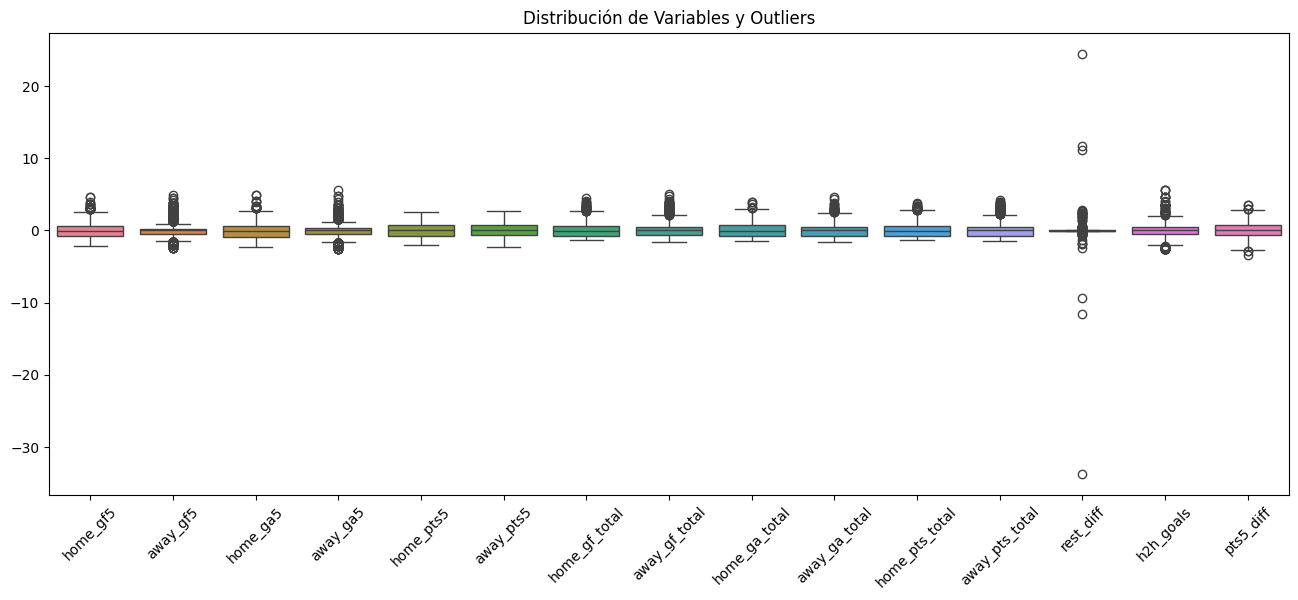

In [ ]:
# Detección de outliers
plt.figure(figsize=(16, 6))
df_viz = (data_matches[features_predictivas] - data_matches[features_predictivas].mean()) / data_matches[features_predictivas].std()
sns.boxplot(data=df_viz)
plt.title("Distribución de Variables y Outliers")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# División train / test
mask_test = data_matches['season'] >= 2024
mask_train = data_matches['season'] < 2024

X_train = X[mask_train].copy()
y_train = y[mask_train].copy()
X_test = X[mask_test].copy()
y_test = y[mask_test].copy()

print(f"Train (Histórico 2019-2023): {X_train.shape[0]} partidos")
print(f"Test Final (Futuro 2024 y 2025):    {X_test.shape[0]} partidos")

Train (Histórico 2019-2023): 1900 partidos
Test Final (Futuro 2024 y 2025):    450 partidos


In [ ]:
print("Distribución en TRAIN (2019-2023)")
dist_train = y_train.value_counts(normalize=True).sort_index()
print(dist_train)

print("\nDistribución en TEST (2024-2025)")
dist_test = y_test.value_counts(normalize=True).sort_index()
print(dist_test)

print("\nDiferencia (Test - Train)")
print(dist_test - dist_train)

Distribución en TRAIN (2019-2023)
class_goals
0    0.285263
1    0.469474
2    0.245263
Name: proportion, dtype: float64

Distribución en TEST (2024-2025)
class_goals
0    0.262222
1    0.500000
2    0.237778
Name: proportion, dtype: float64

Diferencia (Test - Train)
class_goals
0   -0.023041
1    0.030526
2   -0.007485
Name: proportion, dtype: float64


In [ ]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Train escalado: {X_train_scaled.shape}")
print(f"Test escalado:  {X_test_scaled.shape}")

Train escalado: (1900, 15)
Test escalado:  (450, 15)


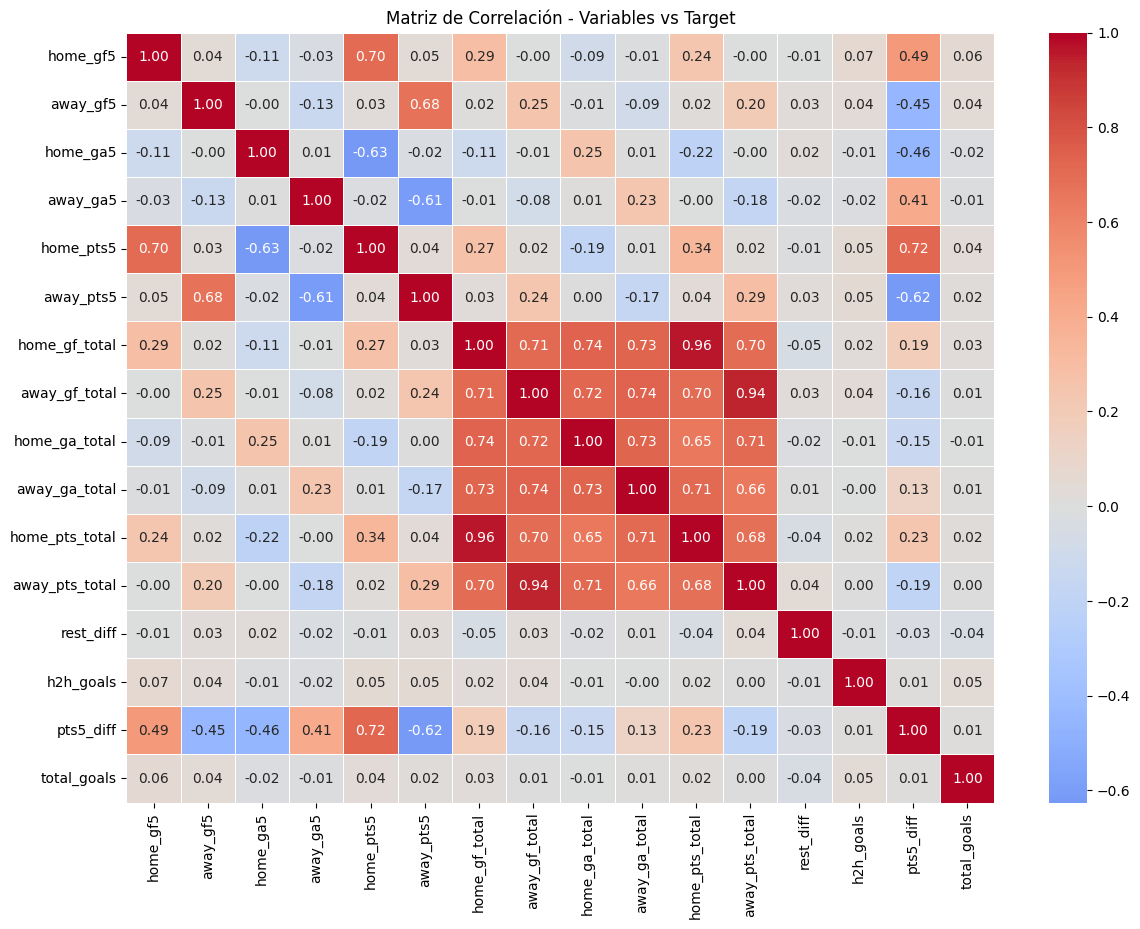

VARIABLES QUE MÁS AFECTAN AL TARGET (Goles)
total_goals       1.000000
home_gf5          0.056930
h2h_goals         0.045136
away_gf5          0.041997
home_pts5         0.035707
home_gf_total     0.031076
away_pts5         0.021396
home_pts_total    0.018361
away_ga_total     0.013819
pts5_diff         0.010610
away_gf_total     0.008070
away_pts_total    0.004683
home_ga_total    -0.008242
away_ga5         -0.012519
home_ga5         -0.019292
rest_diff        -0.040973
Name: total_goals, dtype: float64


In [ ]:
# Correlaciones entre variables
df_analisis = X_train.copy()
df_analisis['total_goals'] = y_train

plt.figure(figsize=(14, 10))
corr_matrix = df_analisis.corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Matriz de Correlación - Variables vs Target")
plt.show()

print("VARIABLES QUE MÁS AFECTAN AL TARGET (Goles)")
print(corr_matrix['total_goals'].sort_values(ascending=False))

/tmp/ipython-input-610170410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='total_goals', data=df_analisis, palette='viridis')


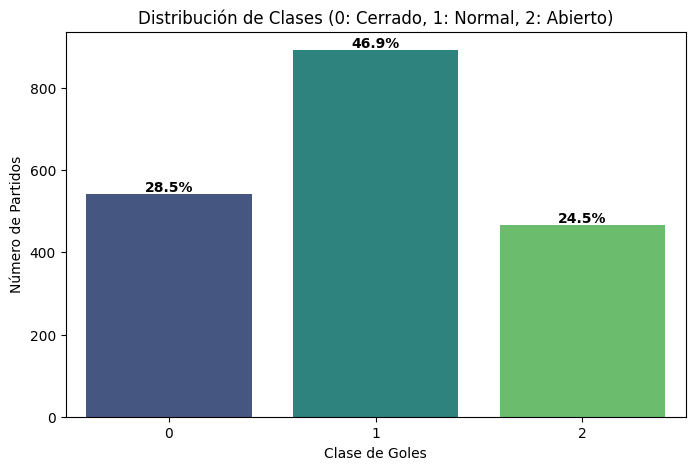

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='total_goals', data=df_analisis, palette='viridis')
plt.title("Distribución de Clases (0: Cerrado, 1: Normal, 2: Abierto)")
plt.xlabel("Clase de Goles")
plt.ylabel("Número de Partidos")
counts = df_analisis['total_goals'].value_counts(normalize=True)
for i, v in counts.items():
    plt.text(i, df_analisis['total_goals'].value_counts()[i], f"{v*100:.1f}%",
             ha='center', va='bottom', fontweight='bold')
plt.show()

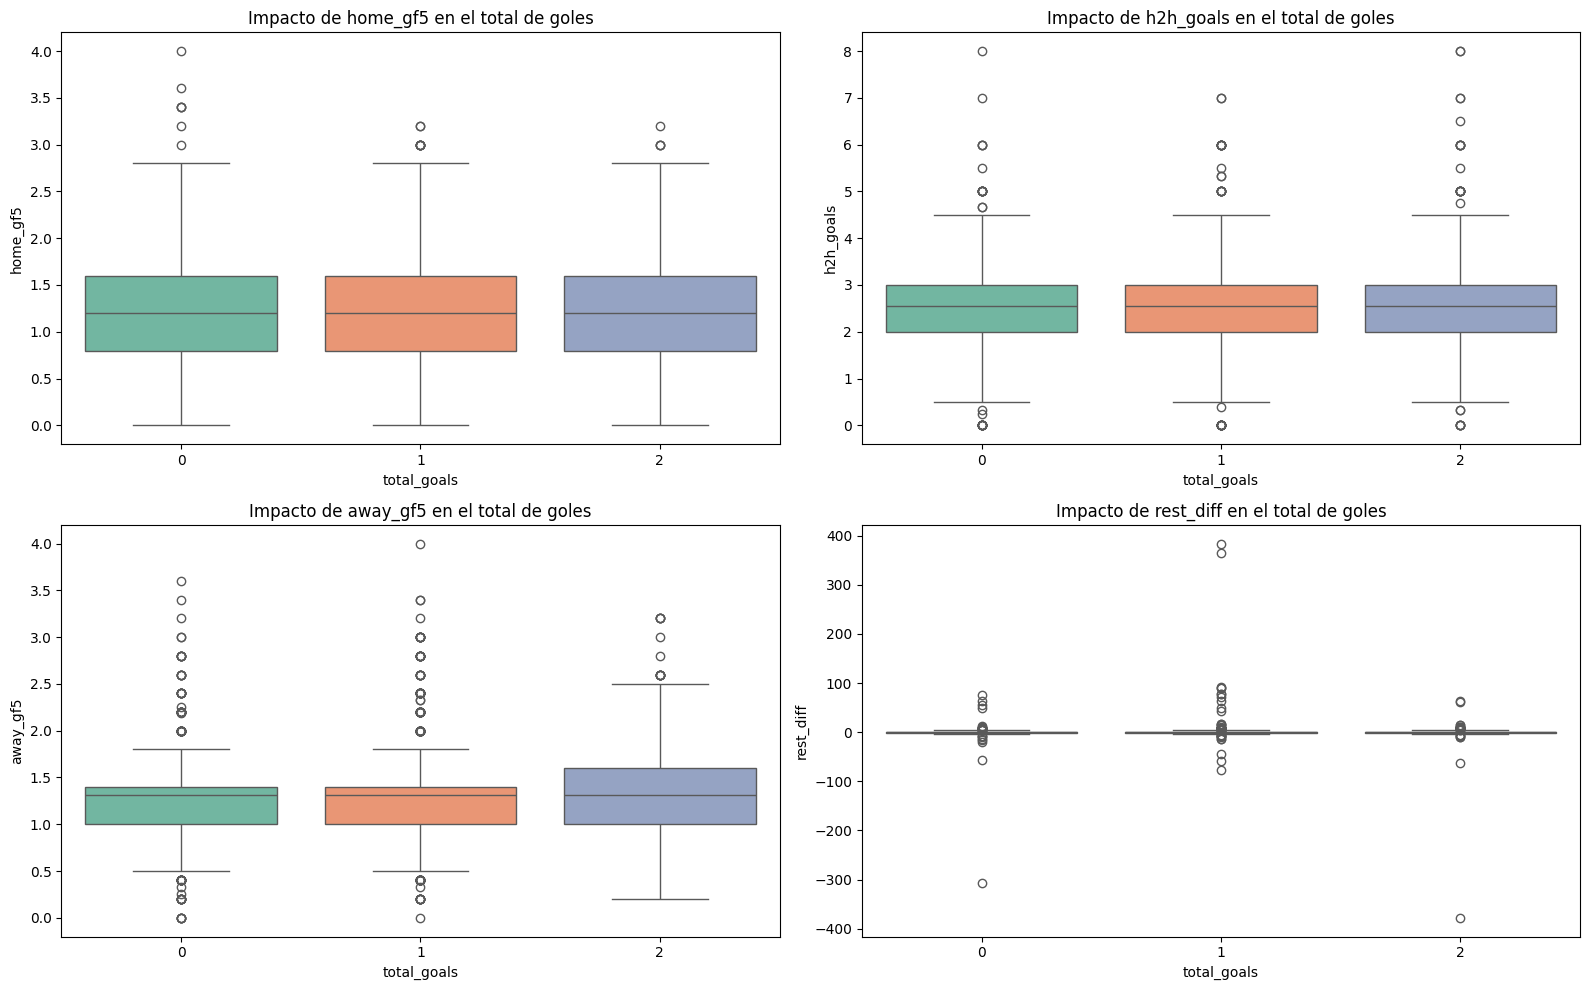

In [ ]:
top_vars = corr_matrix['total_goals'].abs().sort_values(ascending=False).index[1:5]
plt.figure(figsize=(16, 10))
for i, col in enumerate(top_vars):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='total_goals', y=col, hue='total_goals', data=df_analisis, palette='Set2', legend=False)
    plt.title(f"Impacto de {col} en el total de goles")
plt.tight_layout()
plt.show()

De forma no sorprendente, las variables predictivas que influyen más al total de goles, es decir, que tienen mayor correlación positiva, son las que pertenecen al equipo local (home_gf5, home_pts5, home_gf_total). Esto sugiere que la iniciativa ofensiva casi siempre viene dada por el equipo que juega en casa, el visitante influye menos en el total de goles.

Otra variable que tiene bastante peso son los enfrentamientos pasados entre esos dos equipos (H2H), lo que nos sugiere que si en los partidos de Barça y Madrid suele haber goles, seguirán haciéndolo independientemente de la racha actual.

Que las correlaciones sean tan bajas justifica que en el siguiente paso obtendremos mejores resultados con modelos no liniales.

## PCA


Varianza explicada por PC1: 29.90%
Varianza explicada por PC2: 21.23%
Varianza Total acumulada: 51.13%


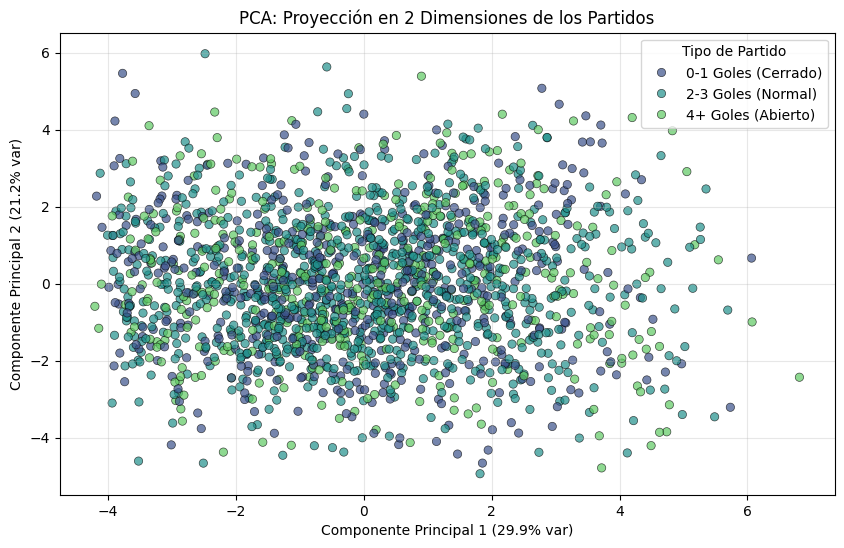

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)


varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza_explicada[0]:.2%}")
print(f"Varianza explicada por PC2: {varianza_explicada[1]:.2%}")
print(f"Varianza Total acumulada: {varianza_explicada.sum():.2%}")


plt.figure(figsize=(10, 6))
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Clase'] = y_train.values

nombres_clases = {0: '0-1 Goles (Cerrado)', 1: '2-3 Goles (Normal)', 2: '4+ Goles (Abierto)'}
df_pca['Etiqueta'] = df_pca['Clase'].map(nombres_clases)

sns.scatterplot(
    x='PC1', y='PC2',
    hue='Etiqueta',
    data=df_pca,
    palette='viridis',
    alpha=0.7,
    edgecolor='k'
)

plt.title('PCA: Proyección en 2 Dimensiones de los Partidos')
plt.xlabel(f'Componente Principal 1 ({varianza_explicada[0]:.1%} var)')
plt.ylabel(f'Componente Principal 2 ({varianza_explicada[1]:.1%} var)')
plt.legend(title='Tipo de Partido')
plt.grid(True, alpha=0.3)
plt.show()

## t-SNE

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


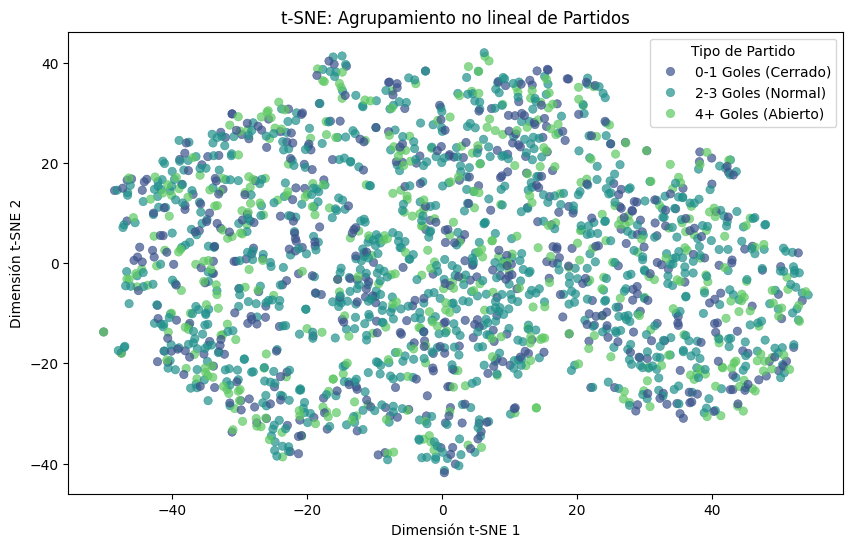

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))

df_tsne = pd.DataFrame(data=X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Clase'] = y_train.values
df_tsne['Etiqueta'] = df_tsne['Clase'].map(nombres_clases)

sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='Etiqueta',
    data=df_tsne,
    palette='viridis',
    alpha=0.7,
    edgecolor=None
)

plt.title('t-SNE: Agrupamiento no lineal de Partidos')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Tipo de Partido')
plt.show()

## Clustering


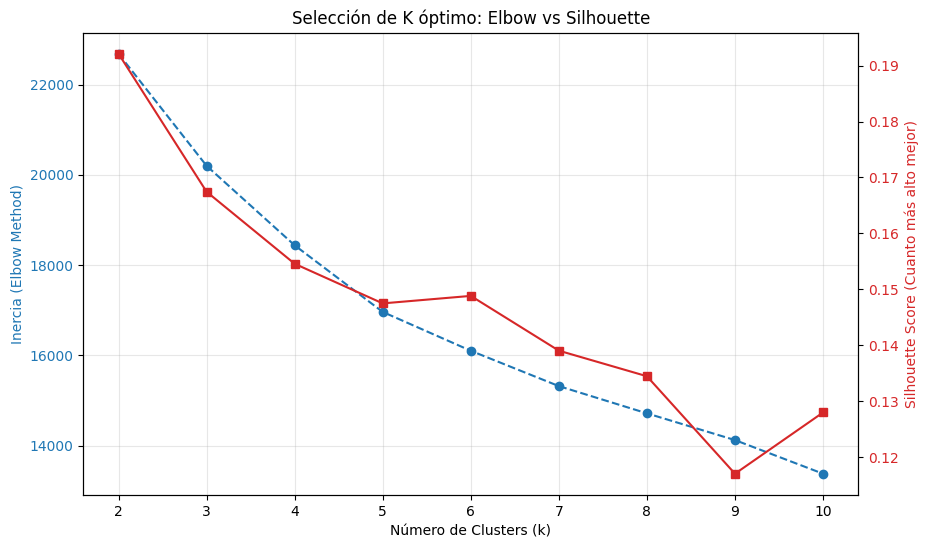

In [ ]:
k_range = range(2, 11)
inertias = []
silhouettes = []

X_cluster = X_train_scaled.copy()


for k in k_range:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

    s_score = silhouette_score(X_cluster, kmeans.labels_)
    silhouettes.append(s_score)

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Elbow Method)', color=color)
ax1.plot(k_range, inertias, 'o--', color=color, label='Inercia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)


ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score (Cuanto más alto mejor)', color=color)
ax2.plot(k_range, silhouettes, 's-', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Selección de K óptimo: Elbow vs Silhouette')
plt.show()

best_k = k_range[np.argmax(silhouettes)]


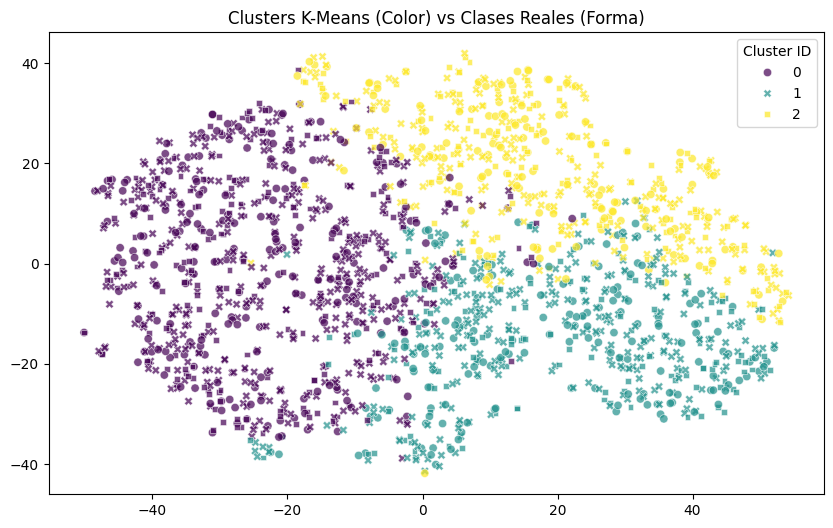


 Tabla de Contingencia (Realidad vs Clusters)
Cluster K-Means         0    1    2
Goles Reales (0,1,2)               
0                     233  162  147
1                     387  271  234
2                     201  134  131


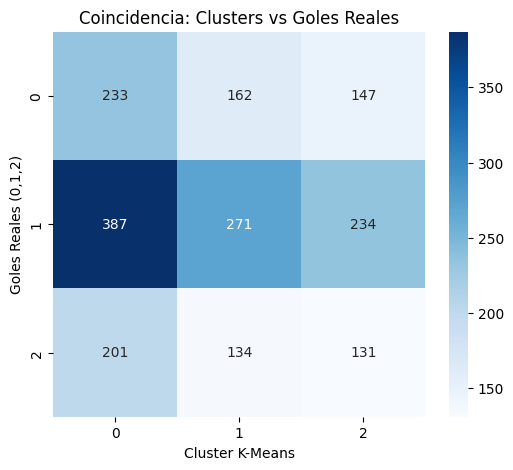

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_train_scaled)

X_train_con_cluster = X_train_scaled.copy()
X_train_con_cluster['cluster_id'] = clusters
X_train_con_cluster['Clase_Real'] = y_train.values

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=clusters,
    palette='viridis',
    style=y_train.values,
    alpha=0.7
)
plt.title('Clusters K-Means (Color) vs Clases Reales (Forma)')
plt.legend(title='Cluster ID')
plt.show()


contingency_table = pd.crosstab(
    X_train_con_cluster['Clase_Real'],
    X_train_con_cluster['cluster_id'],
    rownames=['Goles Reales (0,1,2)'],
    colnames=['Cluster K-Means']
)

print("\n Tabla de Contingencia (Realidad vs Clusters)")
print(contingency_table)


plt.figure(figsize=(6, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
plt.title('Coincidencia: Clusters vs Goles Reales')
plt.show()

In [ ]:
columnas_originales = X_train.columns.tolist()

print(f" Columnas originales identificadas: {len(columnas_originales)}")
print(f" Columnas actuales en X_train_scaled: {X_train_scaled.shape[1]}")

X_train_clean = X_train_scaled[columnas_originales].copy()
X_test_clean = X_test_scaled[columnas_originales].copy()

best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_train_clean)

X_train_scaled['cluster_id'] = kmeans.labels_
X_test_scaled['cluster_id'] = kmeans.predict(X_test_clean)

distancias_train = cdist(X_train_clean, kmeans.cluster_centers_, metric='euclidean')
distancias_test = cdist(X_test_clean, kmeans.cluster_centers_, metric='euclidean')

for i in range(best_k):
    col_name = f'dist_centroide_{i}'
    X_train_scaled[col_name] = distancias_train[:, i]
    X_test_scaled[col_name] = distancias_test[:, i]

print(f" Añadidas {best_k} columnas de distancia.")
print(f" Shape final X_train_scaled: {X_train_scaled.shape}")

 Columnas originales identificadas: 15
 Columnas actuales en X_train_scaled: 15
 Añadidas 3 columnas de distancia.
 Shape final X_train_scaled: (1900, 19)


In [ ]:
cols_distancias = [f'dist_centroide_{i}' for i in range(3)]

print(f"Usando columnas de distancias existentes: {cols_distancias}")


id_train = X_train_scaled['cluster_id'].astype(int).values
id_test = X_test_scaled['cluster_id'].astype(int).values

dist_propia_train = X_train_scaled[cols_distancias].values[np.arange(len(id_train)), id_train]
dist_propia_test = X_test_scaled[cols_distancias].values[np.arange(len(id_test)), id_test]

X_train_scaled['dist_centroide_propio'] = dist_propia_train
X_test_scaled['dist_centroide_propio'] = dist_propia_test


dists_sorted_train = np.sort(X_train_scaled[cols_distancias].values, axis=1)
dists_sorted_test = np.sort(X_test_scaled[cols_distancias].values, axis=1)

# ratio = (Distancia 1) / (Distancia 2 + epsilon)
epsilon = 1e-6
X_train_scaled['ratio_ambiguedad'] = dists_sorted_train[:, 0] / (dists_sorted_train[:, 1] + epsilon)
X_test_scaled['ratio_ambiguedad'] = dists_sorted_test[:, 0] / (dists_sorted_test[:, 1] + epsilon)


X_train_scaled['es_frontera'] = (X_train_scaled['ratio_ambiguedad'] > 0.85).astype(int)
X_test_scaled['es_frontera'] = (X_test_scaled['ratio_ambiguedad'] > 0.85).astype(int)

print(f"Añadidas columnas: 'ratio_ambiguedad' y 'es_frontera'")
print(f" Partidos frontera en Train: {X_train_scaled['es_frontera'].sum()}")



Usando columnas de distancias existentes: ['dist_centroide_0', 'dist_centroide_1', 'dist_centroide_2']
Añadidas columnas: 'ratio_ambiguedad' y 'es_frontera'
 Partidos frontera en Train: 486


In [ ]:
cols_excluir = cols_distancias + ['cluster_id', 'dist_centroide_propio', 'ratio_ambiguedad', 'es_frontera']

cols_features = [c for c in X_train_scaled.columns
                 if c not in cols_excluir and not c.startswith('cluster_')]

print(f"Columnas usadas para Silhouette: {len(cols_features)}")

sil_train = silhouette_samples(X_train_scaled[cols_features], id_train)
# Para test, lo calculamos también
sil_test = silhouette_samples(X_test_scaled[cols_features], id_test)

X_train_scaled['silhouette_individual'] = sil_train
X_test_scaled['silhouette_individual'] = sil_test


dummies_train = pd.get_dummies(X_train_scaled['cluster_id'], prefix='cluster')
dummies_test = pd.get_dummies(X_test_scaled['cluster_id'], prefix='cluster')

X_train_scaled = pd.concat([X_train_scaled, dummies_train], axis=1)
X_test_scaled = pd.concat([X_test_scaled, dummies_test], axis=1)

print(f"Total columnas final: {X_train_scaled.shape[1]}")
print("Variables nuevas añadidas:")
nuevas = [c for c in X_train_scaled.columns if c not in cols_features]
print(nuevas)

Columnas usadas para Silhouette: 15
Total columnas final: 26
Variables nuevas añadidas:
['cluster_id', 'dist_centroide_0', 'dist_centroide_1', 'dist_centroide_2', 'dist_centroide_propio', 'ratio_ambiguedad', 'es_frontera', 'silhouette_individual', 'cluster_0', 'cluster_1', 'cluster_2']


Top 5 variables que diferencian los clusters: ['dist_centroide_0', 'dist_centroide_2', 'home_pts_total', 'home_gf_total', 'home_ga_total']

Promedios por Cluster (en las variables clave):
            dist_centroide_0  dist_centroide_2  home_pts_total  home_gf_total  \
cluster_id                                                                      
0                   2.946002          4.852802       -0.828294      -0.856034   
1                   4.737014          4.441299        0.282232       0.368571   
2                   4.830573          3.021052        1.015633       0.964501   

            home_ga_total  Goles_Reales  
cluster_id                               
0               -0.813842      0.961023  
1                0.902219      0.950617  
2                0.305871      0.968750  


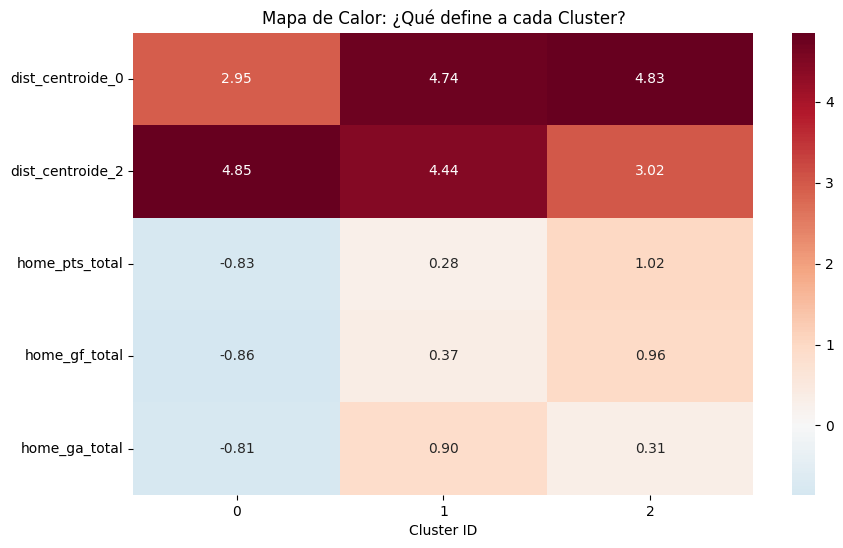

In [ ]:
df_analisis = X_train_scaled.copy()
df_analisis['Goles_Reales'] = y_train.values

perfil = df_analisis.groupby('cluster_id').mean()

diferencias = perfil.std().sort_values(ascending=False)
top_vars = diferencias.head(5).index.tolist()

print(f"Top 5 variables que diferencian los clusters: {top_vars}")
print("\nPromedios por Cluster (en las variables clave):")
print(perfil[top_vars + ['Goles_Reales']])

plt.figure(figsize=(10, 6))
sns.heatmap(perfil[top_vars].T, cmap='RdBu_r', center=0, annot=True, fmt='.2f')
plt.title('Mapa de Calor: ¿Qué define a cada Cluster?')
plt.xlabel('Cluster ID')
plt.show()

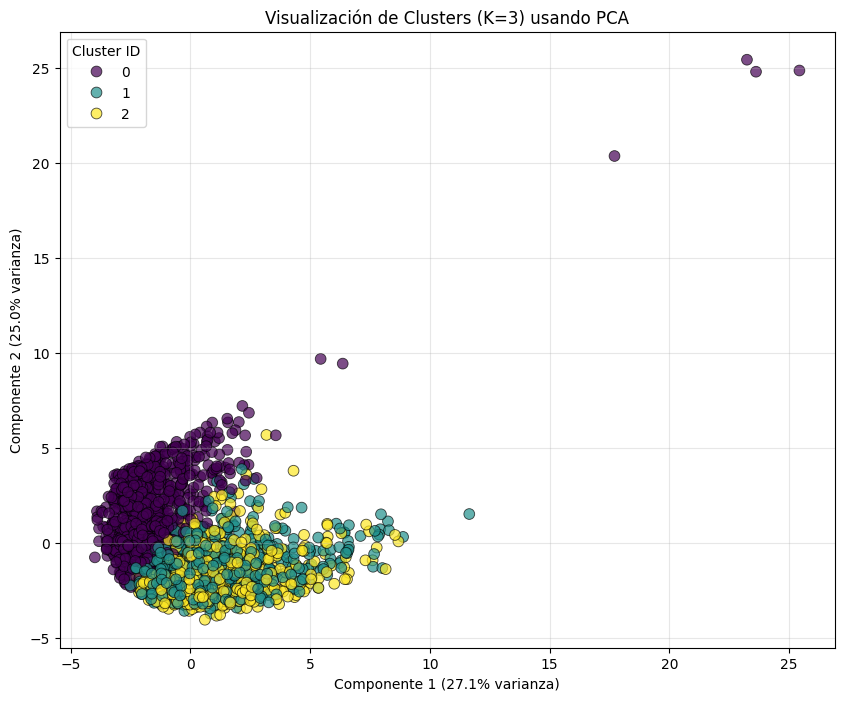

In [ ]:
cols_pca = [c for c in X_train_scaled.columns if 'cluster' not in c and 'es_frontera' not in c]
X_pca_input = X_train_scaled[cols_pca]

pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_pca_input)

df_pca = pd.DataFrame(data=componentes, columns=['PC1', 'PC2'])
df_pca['Cluster'] = X_train_scaled['cluster_id'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    data=df_pca,
    palette='viridis',
    s=60, alpha=0.7,
    edgecolor='k'
)
plt.title(f'Visualización de Clusters (K={best_k}) usando PCA')
plt.xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

# Aplicación modelos lineales

A continuación vamos a aplicar los 3 modelos siguientes con sus mejores hiperparámetros: Regresión Logística, SVM lineal y KNN.

Fitting 5 folds for each of 5 candidates, totalling 25 fits

MEJOR RESULTADO (Validación Cruzada Temporal):
F1-Macro: 0.3371
Mejores Parámetros: {'model__C': 0.1, 'model__solver': 'lbfgs'}

Accuracy Global (sobre Train): 0.391

Informe de Clasificación (Train):
              precision    recall  f1-score   support

     Cerrado       0.32      0.35      0.34       542
      Normal       0.54      0.39      0.45       892
     Abierto       0.31      0.43      0.36       466

    accuracy                           0.39      1900
   macro avg       0.39      0.39      0.38      1900
weighted avg       0.42      0.39      0.40      1900



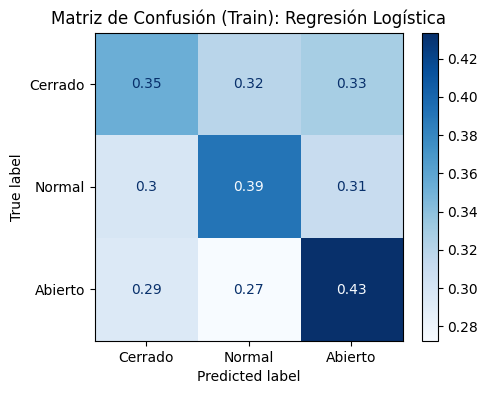

In [ ]:
cv = TimeSeriesSplit(n_splits=5)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print(f"\nMEJOR RESULTADO (Validación Cruzada Temporal):")
print(f"F1-Macro: {grid_lr.best_score_:.4f}")
print(f"Mejores Parámetros: {grid_lr.best_params_}")

best_model_lr = grid_lr.best_estimator_
y_pred_lr = best_model_lr.predict(X_train)

print(f"\nAccuracy Global (sobre Train): {accuracy_score(y_train, y_pred_lr):.3f}")
print("\nInforme de Clasificación (Train):")
print(classification_report(y_train, y_pred_lr, target_names=['Cerrado', 'Normal', 'Abierto']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_lr,
    display_labels=['Cerrado', 'Normal', 'Abierto'],
    cmap='Blues', normalize='true', ax=ax
)
plt.title("Matriz de Confusión (Train): Regresión Logística")
plt.show()

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejor F1-Macro: 0.3353
Mejores Parámetros: {'model__C': 1}
Accuracy Global: 0.393

Informe de Clasificación:
              precision    recall  f1-score   support

     Cerrado       0.32      0.42      0.36       542
      Normal       0.53      0.38      0.44       892
     Abierto       0.32      0.39      0.35       466

    accuracy                           0.39      1900
   macro avg       0.39      0.39      0.39      1900
weighted avg       0.42      0.39      0.40      1900



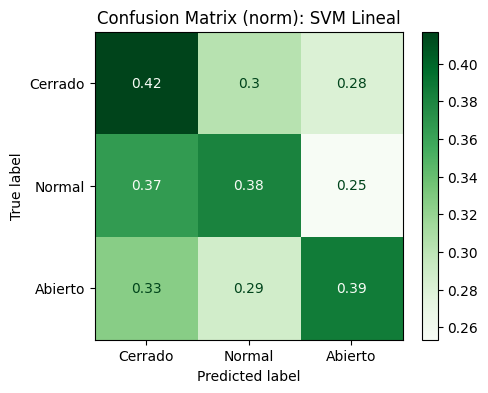

In [ ]:
# SVM
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='linear', class_weight='balanced', random_state=42))
])

param_grid_svm = {
    'model__C': [0.01, 0.1, 1, 10]
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid=param_grid_svm,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

print(f"Mejor F1-Macro: {grid_svm.best_score_:.4f}")
print(f"Mejores Parámetros: {grid_svm.best_params_}")

best_model_svm = grid_svm.best_estimator_
y_pred_svm = best_model_svm.predict(X_train)


print(f"Accuracy Global: {accuracy_score(y_train, y_pred_svm):.3f}")
print("\nInforme de Clasificación:")
print(classification_report(y_train, y_pred_svm, target_names=['Cerrado', 'Normal', 'Abierto']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_svm,
    display_labels=['Cerrado', 'Normal', 'Abierto'],
    cmap='Greens', normalize='true', ax=ax
)
plt.title("Confusion Matrix (norm): SVM Lineal")
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits

MEJOR RESULTADO (Validación Cruzada Temporal):
F1-Macro: 0.3256
Mejores Parámetros: {'model__n_neighbors': 10, 'model__weights': 'uniform'}

Accuracy Global (Train): 0.534

Informe de Clasificación (Train):
              precision    recall  f1-score   support

     Cerrado       0.47      0.41      0.44       542
      Normal       0.56      0.77      0.65       892
     Abierto       0.52      0.22      0.31       466

    accuracy                           0.53      1900
   macro avg       0.52      0.47      0.47      1900
weighted avg       0.52      0.53      0.51      1900



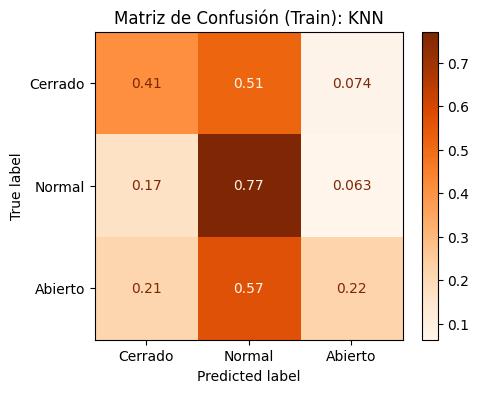

In [ ]:
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid_knn = {
    'model__n_neighbors': [5, 10, 15, 20, 30, 50],
    'model__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    pipe_knn,
    param_grid=param_grid_knn,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train, y_train)

print(f"\nMEJOR RESULTADO (Validación Cruzada Temporal):")
print(f"F1-Macro: {grid_knn.best_score_:.4f}")
print(f"Mejores Parámetros: {grid_knn.best_params_}")

best_model_knn = grid_knn.best_estimator_
y_pred_knn = best_model_knn.predict(X_train)

print(f"\nAccuracy Global (Train): {accuracy_score(y_train, y_pred_knn):.3f}")
print("\nInforme de Clasificación (Train):")
print(classification_report(y_train, y_pred_knn, target_names=['Cerrado', 'Normal', 'Abierto']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_knn,
    display_labels=['Cerrado', 'Normal', 'Abierto'],
    cmap='Oranges', normalize='true', ax=ax
)
plt.title("Matriz de Confusión (Train): KNN")
plt.show()

In [ ]:
# RANDOM FOREST CON VARIABLE OBJETIVO 2.5

y_binaria = (data_matches['home_goals'] + data_matches['away_goals']) > 2.5
y_binaria = y_binaria.astype(int)


limit = int(len(X) * 0.80)

X_train_bin = X.iloc[:limit]
X_test_bin = X.iloc[limit:]
y_train_bin = y_binaria.iloc[:limit]
y_test_bin = y_binaria.iloc[limit:]

# 3. Entrenar Random Forest Robusto (Configuración ligera)
from sklearn.ensemble import RandomForestClassifier

rf_binario = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,            # Poca profundidad
    min_samples_leaf=10,
    class_weight='balanced', # Importante porque suele haber más Under que Over
    random_state=42
)

print("Entrenando modelo binario...")
rf_binario.fit(X_train_bin, y_train_bin)

# 4. Resultados
acc_train = rf_binario.score(X_train_bin, y_train_bin)
acc_test = rf_binario.score(X_test_bin, y_test_bin)

print(f"\nAccuracy Train (Binario): {acc_train:.3f}")
print(f"Accuracy Test (Binario): {acc_test:.3f}") # ¡Ojalá > 0.55!

# Informe final
from sklearn.metrics import classification_report
y_pred_bin = rf_binario.predict(X_test_bin)
print(classification_report(y_test_bin, y_pred_bin, target_names=['Under 2.5 (- goles)', 'Over 2.5 (+ goles)']))

Entrenando modelo binario...

Accuracy Train (Binario): 0.838
Accuracy Test (Binario): 0.772
                     precision    recall  f1-score   support

Under 2.5 (- goles)       0.72      0.90      0.80       242
 Over 2.5 (+ goles)       0.86      0.63      0.73       228

           accuracy                           0.77       470
          macro avg       0.79      0.77      0.77       470
       weighted avg       0.79      0.77      0.77       470



# Modelos no lineales

Entrenando Modelo Robusto...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Accuracy en TRAIN (Debería bajar del 89%): 0.556
Accuracy en TEST (Esperamos mejora o estabilidad): 0.331

--- INFORME TEST ---
              precision    recall  f1-score   support

     Cerrado       0.21      0.26      0.23       118
      Normal       0.48      0.36      0.41       225
     Abierto       0.27      0.35      0.31       107

    accuracy                           0.33       450
   macro avg       0.32      0.32      0.32       450
weighted avg       0.36      0.33      0.34       450



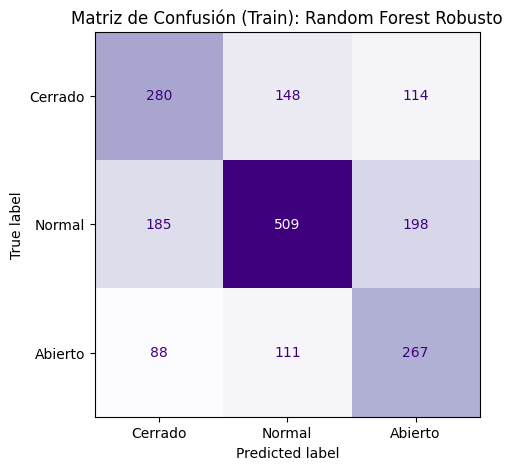

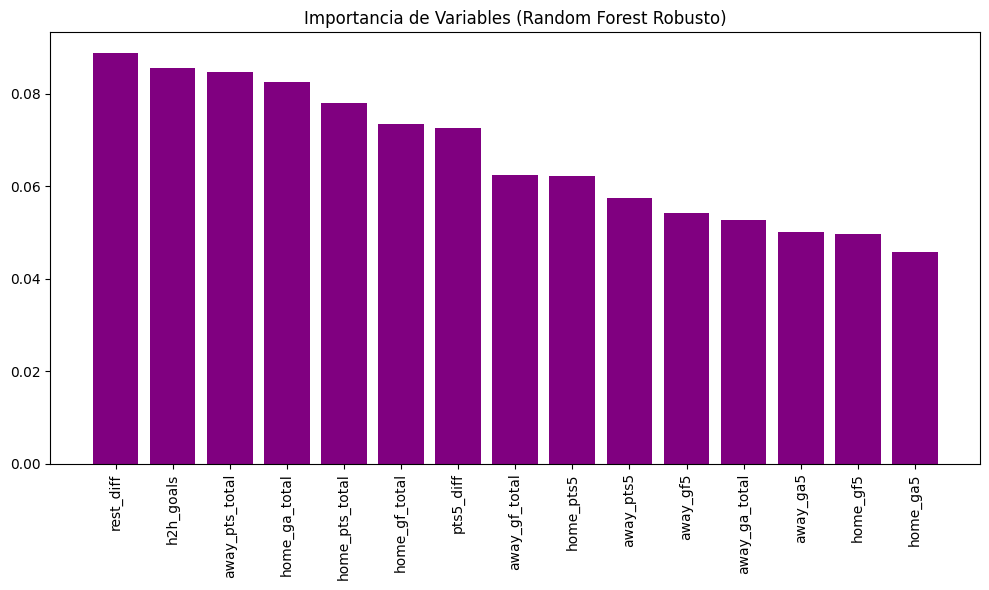

In [ ]:

param_grid_rf_robust = {
    'n_estimators': [200],
    'max_depth': [3, 5],
    'min_samples_leaf': [10, 20],
    'max_features': ['sqrt', 'log2']
}

grid_rf_robust = GridSearchCV(
    rf,
    param_grid=param_grid_rf_robust,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Entrenando Modelo Robusto...")
grid_rf_robust.fit(X_train, y_train)

best_rf_robust = grid_rf_robust.best_estimator_


print(f"\nAccuracy en TRAIN (Debería bajar del 89%): {best_rf_robust.score(X_train, y_train):.3f}")
print(f"Accuracy en TEST (Esperamos mejora o estabilidad): {best_rf_robust.score(X_test, y_test):.3f}")


y_pred_robust = best_rf_robust.predict(X_test)
print("\n--- INFORME TEST ---")
print(classification_report(y_test, y_pred_robust, target_names=['Cerrado', 'Normal', 'Abierto']))

y_pred_train_robust = best_rf_robust.predict(X_train)


fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train_robust,
    display_labels=['Cerrado', 'Normal', 'Abierto'],
    cmap='Purples',
    values_format="d",
    colorbar=False,
    ax=ax
)
plt.title("Matriz de Confusión (Train): Random Forest Robusto")
plt.show()


importances = best_rf_robust.feature_importances_

try:
    feature_names = X_train.columns
except AttributeError:
    print("X_train es un array, usando índices numéricos.")
    feature_names = [f"Var {i}" for i in range(X_train.shape[1])]

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Importancia de Variables (Random Forest Robusto)")
plt.bar(range(len(importances)), importances[indices], align="center", color='purple')
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 8 candidates, totalling 40 fits

MEJOR RESULTADO (Validación Cruzada Temporal):
F1-Macro: 0.3373
Mejores Parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Accuracy Global (Train): 0.749

Informe de Clasificación (Train):
              precision    recall  f1-score   support

     Cerrado       0.92      0.57      0.70       542
      Normal       0.67      0.98      0.79       892
     Abierto       0.94      0.52      0.67       466

    accuracy                           0.75      1900
   macro avg       0.84      0.69      0.72      1900
weighted avg       0.81      0.75      0.74      1900



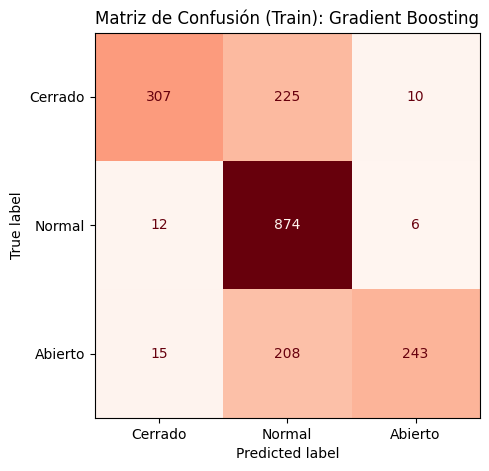

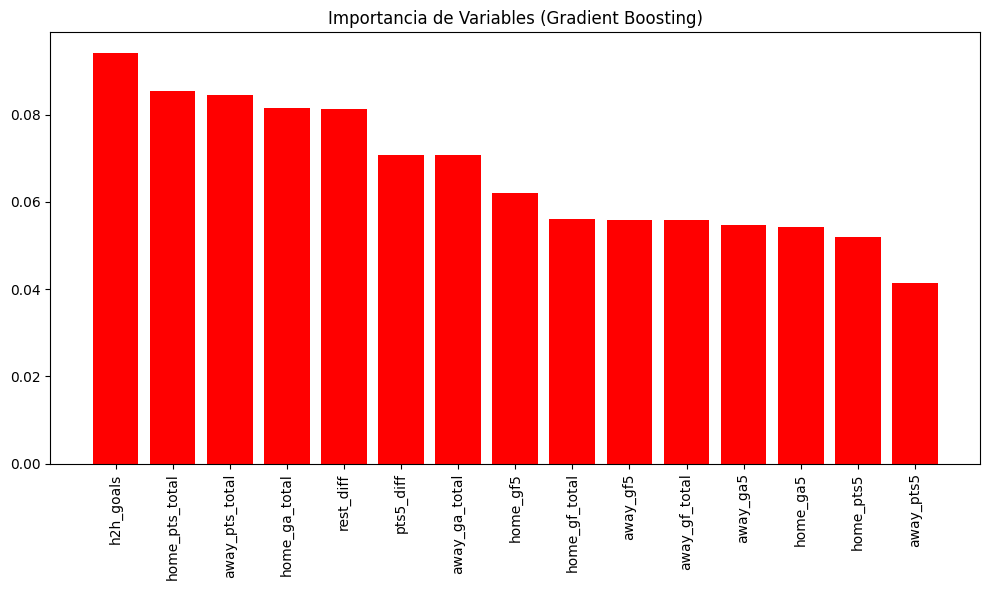

In [ ]:
gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    gb,
    param_grid=param_grid_gb,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)

print(f"\nMEJOR RESULTADO (Validación Cruzada Temporal):")
print(f"F1-Macro: {grid_gb.best_score_:.4f}")
print(f"Mejores Parámetros: {grid_gb.best_params_}")

best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(X_train)

print(f"\nAccuracy Global (Train): {accuracy_score(y_train, y_pred_gb):.3f}")
print("\nInforme de Clasificación (Train):")
print(classification_report(y_train, y_pred_gb, target_names=['Cerrado', 'Normal', 'Abierto']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_gb,
    display_labels=['Cerrado', 'Normal', 'Abierto'],
    cmap='Reds',
    values_format="d",
    colorbar=False,
    ax=ax
)
plt.title("Matriz de Confusión (Train): Gradient Boosting")
plt.show()

importances_gb = best_gb.feature_importances_

try:
    feature_names = X_train.columns
except AttributeError:
    print("Aviso: X_train es un array, usando índices numéricos.")
    feature_names = [f"Var {i}" for i in range(X_train.shape[1])]

indices_gb = np.argsort(importances_gb)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Importancia de Variables (Gradient Boosting)")
plt.bar(range(len(importances_gb)), importances_gb[indices_gb], align="center", color='red')
plt.xticks(range(len(importances_gb)), np.array(feature_names)[indices_gb], rotation=90)
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejor F1-Macro: 0.355
Mejores Parámetros: {'svc__C': 10, 'svc__gamma': 0.01}
Accuracy Global: 0.463
              precision    recall  f1-score   support

     Cerrado       0.40      0.37      0.38       542
      Normal       0.57      0.54      0.55       892
     Abierto       0.36      0.44      0.40       466

    accuracy                           0.46      1900
   macro avg       0.44      0.45      0.44      1900
weighted avg       0.47      0.46      0.47      1900



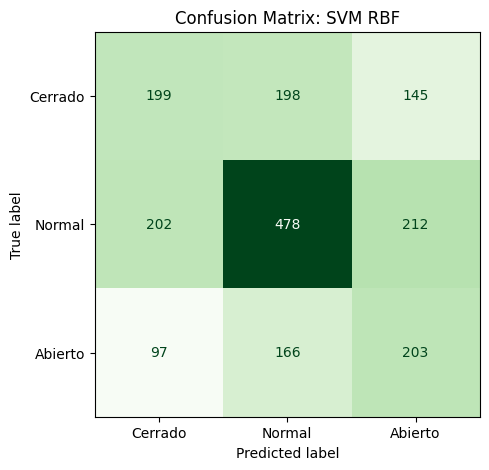

In [ ]:
pipe_rbf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced', random_state=42)
)

param_grid_rbf = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.1, 0.01]
}
grid_rbf = GridSearchCV(
    pipe_rbf,
    param_grid=param_grid_rbf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_rbf.fit(X_train, y_train)

print(f"Mejor F1-Macro: {grid_rbf.best_score_:.3f}")
print(f"Mejores Parámetros: {grid_rbf.best_params_}")

best_rbf = grid_rbf.best_estimator_
y_pred_rbf = best_rbf.predict(X_train)

print(f"Accuracy Global: {accuracy_score(y_train, y_pred_rbf):.3f}")
print(classification_report(y_train, y_pred_rbf, target_names=['Cerrado', 'Normal', 'Abierto']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_rbf,
    display_labels=['Cerrado', 'Normal', 'Abierto'],
    cmap='Greens',
    values_format="d",
    colorbar=False,
    ax=ax
)
plt.title("Confusion Matrix: SVM RBF")
plt.show()

INFORME DE CLASIFICACIÓN (TEST 2024-2025)
              precision    recall  f1-score   support

     Cerrado       0.23      0.23      0.23       118
      Normal       0.51      0.52      0.51       225
     Abierto       0.28      0.26      0.27       107

    accuracy                           0.38       450
   macro avg       0.34      0.34      0.34       450
weighted avg       0.38      0.38      0.38       450



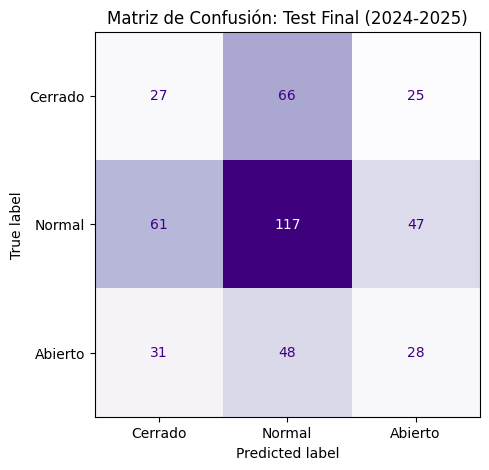

In [ ]:
rf_lock = grid_rf.best_estimator_

X_test_lock = X_test
y_test_lock = y_test

y_pred_final = rf_lock.predict(X_test_lock)

print("INFORME DE CLASIFICACIÓN (TEST 2024-2025)")
print(classification_report(y_test_lock, y_pred_final, target_names=['Cerrado', 'Normal', 'Abierto']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_lock, y_pred_final,
    display_labels=['Cerrado', 'Normal', 'Abierto'],
    cmap='Purples',
    values_format="d",
    colorbar=False,
    ax=ax
)
plt.title("Matriz de Confusión: Test Final (2024-2025)")
plt.show()

El objetivo de este bloque es realizar la prueba de fuego. Hasta ahora, el modelo había estudiado con datos hasta 2023 (train). Con este código, vamos a ver si realmente ha aprendido patrones o si solo se había memorizado el pasado.

Accuracy Final: 0.3822

Informe de Clasificación:
              precision    recall  f1-score   support

     Cerrado       0.23      0.23      0.23       118
      Normal       0.51      0.52      0.51       225
     Abierto       0.28      0.26      0.27       107

    accuracy                           0.38       450
   macro avg       0.34      0.34      0.34       450
weighted avg       0.38      0.38      0.38       450



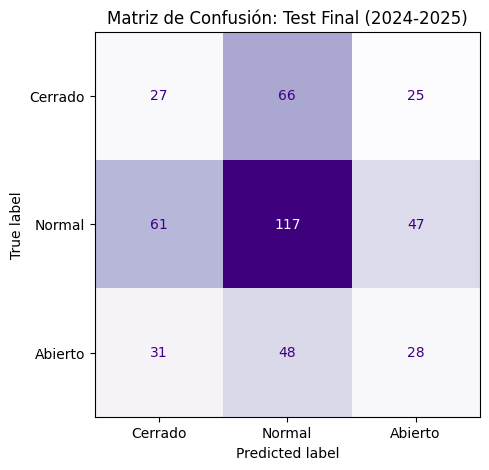

In [ ]:
y_pred_final = best_rf.predict(X_test)

acc_final = accuracy_score(y_test, y_pred_final)
print(f"Accuracy Final: {acc_final:.4f}")

print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_final, target_names=['Cerrado', 'Normal', 'Abierto']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Cerrado', 'Normal', 'Abierto'],
    cmap='Purples',
    values_format="d",
    colorbar=False,
    ax=ax
)
plt.title("Matriz de Confusión: Test Final (2024-2025)")
plt.show()

A continuación se quiere ver qué variables tiene más en cuenta el modelo lineal Regresión Logística, comparado con las variables que tenía en cuenta el modelo de Random Forest.

In [ ]:
lr_analisis = LogisticRegression(max_iter=2000, class_weight='balanced', C=0.1, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
lr_analisis.fit(X_train_scaled, y_train)

coefs_lr = np.mean(np.abs(lr_analisis.coef_), axis=0)

# lo importamos del modelo de Random Forest
importancia_arbol = best_rf.feature_importances_

df_9 = pd.DataFrame({
    'Variable': X_train.columns,
    'Peso_Lineal': coefs_lr,
    'Importancia_Arbol': importancia_arbol
})

# Normalizamos para comparar
df_9['Peso_Lineal'] = df_9['Peso_Lineal'] / df_9['Peso_Lineal'].max()
df_9['Importancia_Arbol'] = df_9['Importancia_Arbol'] / df_9['Importancia_Arbol'].max()

print("\n--- TABLA PARA APARTADO 9.1 (Top 10 Variables) ---")
print(df_9.sort_values('Importancia_Arbol', ascending=False).head(10))


--- TABLA PARA APARTADO 9.1 (Top 10 Variables) ---
          Variable  Peso_Lineal  Importancia_Arbol
8    home_ga_total     0.367602           1.000000
6    home_gf_total     1.000000           0.927118
10  home_pts_total     0.779696           0.907286
13       h2h_goals     0.388434           0.902789
11  away_pts_total     0.676578           0.873494
14       pts5_diff     0.242026           0.852080
9    away_ga_total     0.559310           0.792213
7    away_gf_total     0.760521           0.780050
12       rest_diff     0.381826           0.749799
0         home_gf5     0.238474           0.712977


In [ ]:
y_pred_test = best_rf.predict(X_test)

df_casos = X_test.copy()
df_casos['Real'] = y_test
df_casos['Predicho'] = y_pred_test

aciertos = df_casos[(df_casos['Real'] == 1) & (df_casos['Predicho'] == 1)]
if not aciertos.empty:
    ejemplo_acierto = aciertos.sample(1, random_state=42)
    print("\n--- EJEMPLO ACIERTO (Para Apartado 9.2) ---")
    print(ejemplo_acierto[['h2h_goals', 'home_gf_total', 'Real', 'Predicho']])


fallos_graves = df_casos[(df_casos['Real'] == 2) & (df_casos['Predicho'] == 0)]

print("\n--- EJEMPLO FALLO (Para Apartado 9.2) ---")
if not fallos_graves.empty:

    ejemplo_fallo = fallos_graves.sort_values('h2h_goals').head(1)
    print(ejemplo_fallo[['h2h_goals', 'home_gf_total', 'Real', 'Predicho']])
else:
    fallos_leves = df_casos[(df_casos['Real'] == 2) & (df_casos['Predicho'] == 1)]
    if not fallos_leves.empty:
        ejemplo_fallo = fallos_leves.sort_values('h2h_goals').head(1)
        print(ejemplo_fallo[['h2h_goals', 'home_gf_total', 'Real', 'Predicho']])
    else:
        print("No se encontraron fallos de Goleada (Clase 2) en el Test.")


--- EJEMPLO ACIERTO (Para Apartado 9.2) ---
      h2h_goals  home_gf_total  Real  Predicho
2060        3.5           16.0     1         1

--- EJEMPLO FALLO (Para Apartado 9.2) ---
      h2h_goals  home_gf_total  Real  Predicho
2174        0.0           24.0     2         0
